In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv
/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import warnings
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import HistGradientBoostingRegressor




warnings.filterwarnings('ignore')

train_data = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/train_data.csv')

test_data = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/test_data.csv')
sample_submission = pd.read_csv('/kaggle/input/engage-2-value-from-clicks-to-conversions/sample_submission.csv')



In [6]:
train_data.columns

Index(['trafficSource.isTrueDirect', 'purchaseValue', 'browser',
       'device.screenResolution', 'trafficSource.adContent',
       'trafficSource.keyword', 'screenSize', 'geoCluster',
       'trafficSource.adwordsClickInfo.slot', 'device.mobileDeviceBranding',
       'device.mobileInputSelector', 'userId', 'trafficSource.campaign',
       'device.mobileDeviceMarketingName', 'geoNetwork.networkDomain',
       'gclIdPresent', 'device.operatingSystemVersion', 'sessionNumber',
       'device.flashVersion', 'geoNetwork.region', 'trafficSource',
       'totals.visits', 'geoNetwork.networkLocation', 'sessionId', 'os',
       'geoNetwork.subContinent', 'trafficSource.medium',
       'trafficSource.adwordsClickInfo.isVideoAd', 'browserMajor',
       'locationCountry', 'device.browserSize',
       'trafficSource.adwordsClickInfo.adNetworkType', 'socialEngagementType',
       'geoNetwork.city', 'trafficSource.adwordsClickInfo.page',
       'geoNetwork.metro', 'pageViews', 'locationZone',
      

In [8]:
print("Train:", train_data.shape)
print("Test:", test_data.shape)

print('-'*20)

print(train_data.head())

Train: (116023, 52)
Test: (29006, 51)
--------------------
  trafficSource.isTrueDirect  purchaseValue            browser  \
0                        NaN            0.0               Edge   
1                       True            0.0             Chrome   
2                       True            0.0             Chrome   
3                        NaN            0.0  Internet Explorer   
4                       True     88950000.0             Chrome   

         device.screenResolution trafficSource.adContent  \
0  not available in demo dataset                     NaN   
1  not available in demo dataset                     NaN   
2  not available in demo dataset                     NaN   
3  not available in demo dataset                     NaN   
4  not available in demo dataset                     NaN   

  trafficSource.keyword screenSize geoCluster  \
0                   NaN     medium   Region_2   
1                   NaN     medium   Region_3   
2        (not provided)     medium  

## **Visualising key statistics**

-  Most values are zero, indicating extreme right skew, with a few very large outliers driving a high mean and standard deviation.

In [9]:
train_data['purchaseValue'].describe()

count    1.160230e+05
mean     2.656393e+07
std      2.051825e+08
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.312950e+10
Name: purchaseValue, dtype: float64

## **EDA**

In [10]:
zero_count = (train_data['purchaseValue'] == 0).sum()
total_count = train_data['purchaseValue'].shape[0]
zero_percent = zero_count / total_count * 100

print(f"Zero values: {zero_count} ({zero_percent:.2f}%) out of {total_count}")


Zero values: 92038 (79.33%) out of 116023


### **Missing values**

In [11]:
missing_values = train_data.isnull().sum()
print(missing_values[missing_values > 0])  # Only show columns with missing values


trafficSource.isTrueDirect                       73133
trafficSource.adContent                         113060
trafficSource.keyword                            71861
trafficSource.adwordsClickInfo.slot             111742
trafficSource.adwordsClickInfo.isVideoAd        111742
trafficSource.adwordsClickInfo.adNetworkType    111742
trafficSource.adwordsClickInfo.page             111742
pageViews                                            8
trafficSource.referralPath                       73309
totals.bounces                                   68875
new_visits                                       35505
dtype: int64


### **Finding Duplicates**

In [12]:
duplicate_rows = train_data.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

duplicate_columns = train_data.T.duplicated().sum()
print(f"Duplicate columns: {duplicate_columns}")


Duplicate rows: 236
Duplicate columns: 12


In [13]:
dupe_cols = train_data.columns[train_data.T.duplicated()]
print("Duplicated columns:", dupe_cols.tolist())


Duplicated columns: ['device.mobileDeviceBranding', 'device.mobileInputSelector', 'device.mobileDeviceMarketingName', 'device.operatingSystemVersion', 'device.flashVersion', 'geoNetwork.networkLocation', 'browserMajor', 'device.browserSize', 'device.mobileDeviceModel', 'device.language', 'device.browserVersion', 'device.screenColors']


In [14]:
# Step 1: Identify duplicated columns
dupe_cols = train_data.columns[train_data.T.duplicated()]

# Step 2: Drop them
train_data = train_data.drop(columns=dupe_cols)

print(f"New shape: {train_data.shape}")
print(f"Duplicate columns left: {train_data.T.duplicated().sum()}")


New shape: (116023, 40)
Duplicate columns left: 0


### **Unique values per column**

In [15]:
unique_counts = train_data.nunique()
print(unique_counts.sort_values())

trafficSource.isTrueDirect                           1
totals.bounces                                       1
locationZone                                         1
socialEngagementType                                 1
trafficSource.adwordsClickInfo.isVideoAd             1
totals.visits                                        1
new_visits                                           1
device.screenResolution                              1
screenSize                                           1
trafficSource.adwordsClickInfo.adNetworkType         2
gclIdPresent                                         2
device.isMobile                                      2
trafficSource.adwordsClickInfo.slot                  3
deviceType                                           3
geoNetwork.networkDomain                             3
trafficSource.adwordsClickInfo.page                  5
geoCluster                                           5
geoNetwork.continent                                 6
trafficSou

In [16]:
constant_columns = [col for col in train_data.columns if train_data[col].nunique() == 1]
print("Constant columns:", constant_columns)


Constant columns: ['trafficSource.isTrueDirect', 'device.screenResolution', 'screenSize', 'totals.visits', 'trafficSource.adwordsClickInfo.isVideoAd', 'socialEngagementType', 'locationZone', 'totals.bounces', 'new_visits']


### **Skewness: 53.91**

Very high positive skew.

- This means the distribution is extremely right-skewed — most purchaseValue entries are zero or small, and a few very large values are pulling the distribution far to the right.

### **Kurtosis: 4635.63**
This is extremely high kurtosis.

- It suggests a sharp peak near the mean (at 0) with very heavy tails — so your data has:

    - Many zeros

    - A few extreme outliers (very high purchases)

In [17]:
train_data['purchaseValue'].skew(), train_data['purchaseValue'].kurt()


(53.90790631995238, 4635.630727330541)

**Raw Purchase Value Distribution**

- most purchases are zero or very low, with a few extremely high outliers skewing the distribution heavily to the right.

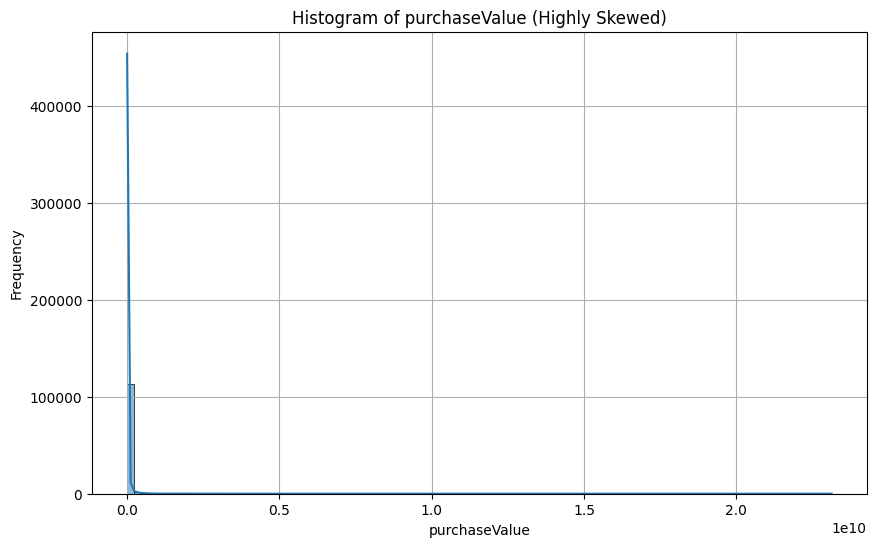

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(train_data['purchaseValue'], bins=100, kde=True)
plt.title('Histogram of purchaseValue (Highly Skewed)')
plt.xlabel('purchaseValue')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


- In the raw plot, everything except the outliers is compressed at the left.

- After log-transform, we can see the spread of low, mid, and high purchase behavior, not just a spike at 0.


- A few huge values dominate the plot, hiding most of the small/mid values.

- Log transformation flattens these large values, making the distribution easier to see and interpret.

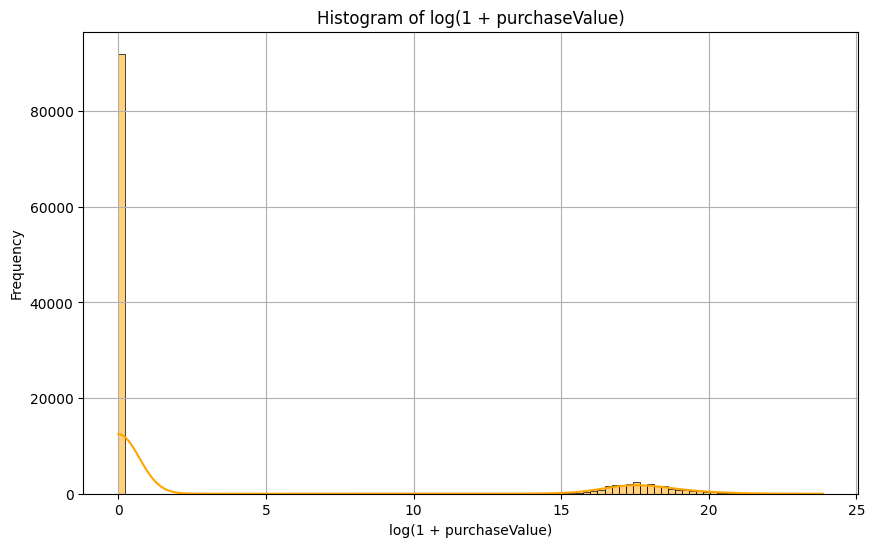

In [19]:
log_purchase = np.log1p(train_data['purchaseValue'])

plt.figure(figsize=(10, 6))
sns.histplot(log_purchase, bins=100, kde=True, color='orange')
plt.title('Histogram of log(1 + purchaseValue)')
plt.xlabel('log(1 + purchaseValue)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#Note: log(0) = infinity, that is why we used log(1 + purchaseValue)



**Non-Zero Purchase Distribution**

- Shows a strongly right-skewed distribution with most non-zero purchases being small(CClose to zero) and a long tail of high-value outliers.

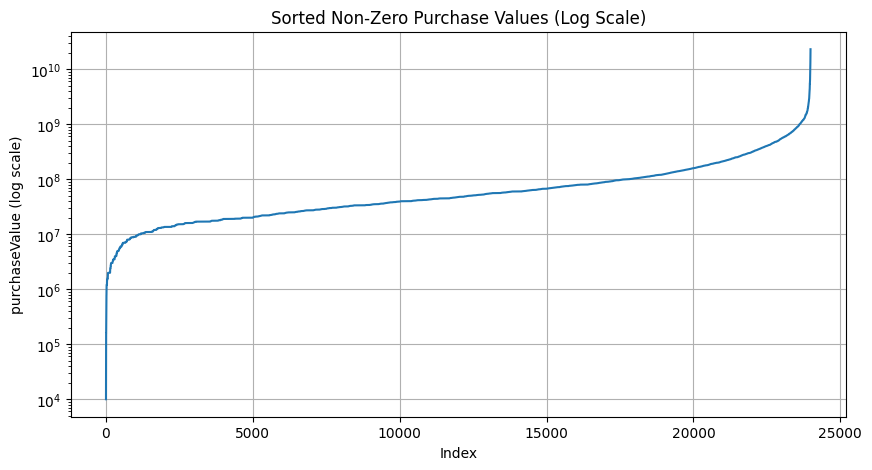

In [20]:
non_zero_values = train_data[train_data['purchaseValue'] > 0]['purchaseValue']
sorted_values = np.sort(non_zero_values)

plt.figure(figsize=(10, 5))
plt.plot(sorted_values)
plt.yscale('log')
plt.title('Sorted Non-Zero Purchase Values (Log Scale)')
plt.xlabel('Index')
plt.ylabel('purchaseValue (log scale)')
plt.grid(True)
plt.show()


In [21]:
# Percentile cutoffs
non_zero = train_data[train_data['purchaseValue'] > 0]['purchaseValue']
percentiles = np.percentile(non_zero, [0, 25, 50, 75, 90, 95, 99, 99.9, 100])
for p, val in zip([0, 25, 50, 75, 90, 95, 99, 99.9, 100], percentiles):
    print(f"{p}th percentile: {val:,.0f}")


0th percentile: 10,000
25th percentile: 23,990,000
50th percentile: 47,700,000
75th percentile: 103,600,000
90th percentile: 262,940,000
95th percentile: 478,400,000
99th percentile: 1,216,422,400
99.9th percentile: 5,392,160,960
100th percentile: 23,129,500,000


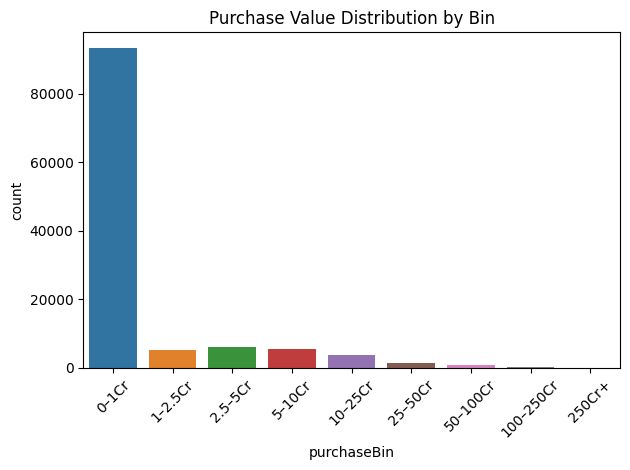

In [22]:
cp_data = train_data.copy()

bins = [0, 1e7, 2.5e7, 5e7, 1e8, 2.5e8, 5e8, 1e9, 2.5e9, 2.5e10]
labels = ['0–1Cr', '1–2.5Cr', '2.5–5Cr', '5–10Cr', '10–25Cr', '25–50Cr', '50–100Cr', '100–250Cr', '250Cr+']

cp_data = cp_data[cp_data['purchaseValue'].notna()]

cp_data['purchaseBin'] = pd.cut(cp_data['purchaseValue'], bins=bins, labels=labels, include_lowest=True)

sns.countplot(data=cp_data, x='purchaseBin', order=labels)
plt.xticks(rotation=45)
plt.title("Purchase Value Distribution by Bin")
plt.tight_layout()
plt.show()


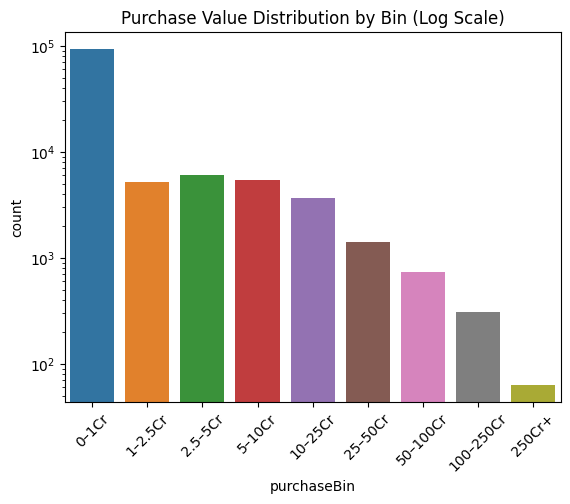

In [23]:
sns.countplot(data=cp_data, x='purchaseBin', order=labels)
plt.yscale('log')  # 🔍 Makes small bars visible
plt.xticks(rotation=45)
plt.title("Purchase Value Distribution by Bin (Log Scale)")
plt.show()


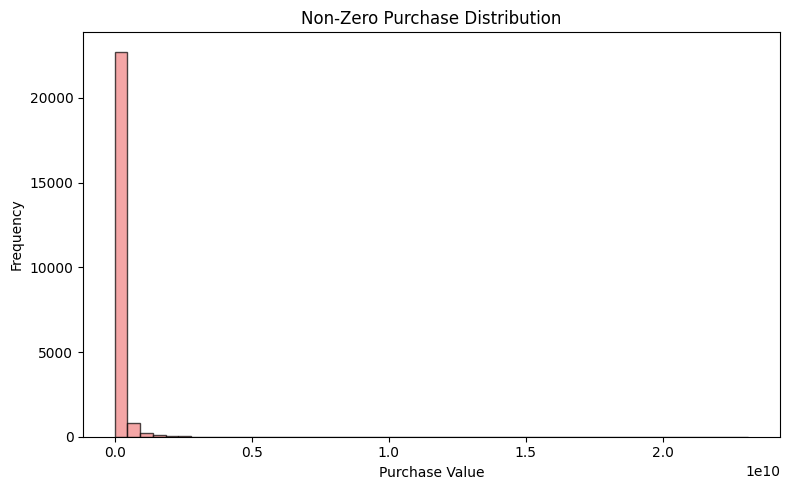

In [24]:
plt.figure(figsize=(8, 5))
non_zero = train_data[train_data['purchaseValue'] > 0]['purchaseValue']
plt.hist(non_zero, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
plt.title('Non-Zero Purchase Distribution')
plt.xlabel('Purchase Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Purchase vs No Purchase Distribution**

- Indicates a class imbalance where 79.3% of users made no purchase, while only 20.7% made a purchase.
- Since most people didn't buy anything, first we can predict who will buy, then we can predict how much they’ll buy — this might gives better results.

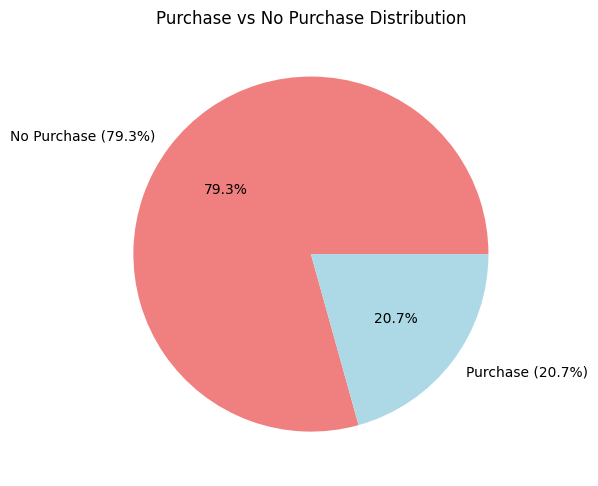

In [25]:
purchase_counts = [
    len(train_data[train_data['purchaseValue'] == 0]),
    len(train_data[train_data['purchaseValue'] > 0])
]

total = sum(purchase_counts)
percentages = [(count / total) * 100 for count in purchase_counts]


labels = [
    f'No Purchase ({percentages[0]:.1f}%)',
    f'Purchase ({percentages[1]:.1f}%)'
]


plt.figure(figsize=(6, 6))
plt.pie(purchase_counts, labels=labels, autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
plt.title('Purchase vs No Purchase Distribution')
plt.tight_layout()
plt.show()


**Feature Correlation Heatmap**

- Most predictive features: totalHits, pageViews, sessionNumber — all strongly positively correlated with purchaseValue.

- Most redundant feature: engagement_ratio — weakly negative correlation, adds little beyond totalHits and pageViews.


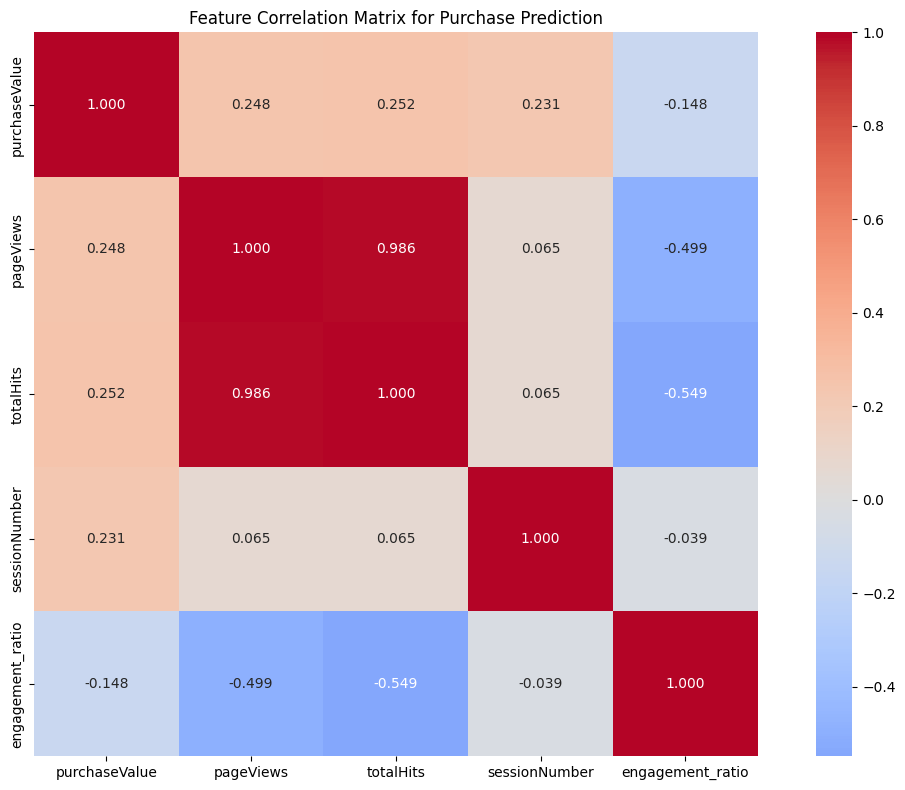

Key Correlations with Purchase Value:
  totalHits           :  0.252
  pageViews           :  0.248
  sessionNumber       :  0.231
  engagement_ratio    : -0.148


In [26]:
cp_train_data = train_data.copy()

cp_train_data['engagement_ratio'] = np.where(
    cp_train_data['totalHits'] == 0, 
    0, 
    cp_train_data['pageViews'] / cp_train_data['totalHits']
)





fig, ax = plt.subplots(1, 1, figsize=(12, 8))

key_features = ['purchaseValue', 'pageViews', 'totalHits', 'sessionNumber', 'engagement_ratio']
correlation_matrix = cp_train_data[key_features].corr()


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', ax=ax)
ax.set_title('Feature Correlation Matrix for Purchase Prediction')
plt.tight_layout()
plt.show()

print("Key Correlations with Purchase Value:")
correlations = correlation_matrix['purchaseValue'].sort_values(ascending=False)
for feature, corr in correlations.items():
    if feature != 'purchaseValue':
        print(f"  {feature:<20}: {corr:6.3f}")


### **Data cleaning**

### Removing missing values greater than 90% in a column

In [27]:
def analyze_missing_values(df, dataset_name):
    missing_percentages = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        'Column': missing_percentages.index,
        'Missing_Percentage': missing_percentages.values
    }).sort_values('Missing_Percentage', ascending=False)
    
    print(f"\n{dataset_name} - Missing Values Analysis:")
    print(missing_df[missing_df['Missing_Percentage'] > 0])
    
    return missing_df

In [28]:
train_missing = analyze_missing_values(train_data, "Training Data")
test_missing = analyze_missing_values(test_data, "Test Data")

high_missing_train = train_missing[train_missing['Missing_Percentage'] > 90]['Column'].tolist()
high_missing_test = test_missing[test_missing['Missing_Percentage'] > 90]['Column'].tolist()

columns_to_drop = list(set(high_missing_train + high_missing_test))

print(f"\nColumns with >90% missing values to be dropped: {columns_to_drop}")

# Drop these columns
train_data = train_data.drop(columns=columns_to_drop, errors='ignore')
test_data = test_data.drop(columns=columns_to_drop, errors='ignore')

print(f"Training data shape after dropping high missing columns: {train_data.shape}")
print(f"Test data shape after dropping high missing columns: {test_data.shape}")



Training Data - Missing Values Analysis:
                                          Column  Missing_Percentage
4                        trafficSource.adContent           97.446196
21      trafficSource.adwordsClickInfo.isVideoAd           96.310214
26           trafficSource.adwordsClickInfo.page           96.310214
23  trafficSource.adwordsClickInfo.adNetworkType           96.310214
8            trafficSource.adwordsClickInfo.slot           96.310214
30                    trafficSource.referralPath           63.184886
0                     trafficSource.isTrueDirect           63.033192
5                          trafficSource.keyword           61.936857
31                                totals.bounces           59.363230
39                                    new_visits           30.601691
28                                     pageViews            0.006895

Test Data - Missing Values Analysis:
                                          Column  Missing_Percentage
31                     

### Imputing missing values with 0 and 'missing'

In [29]:
def impute_missing_values(df):
    df_imputed = df.copy()
    
    numerical_cols = df_imputed.select_dtypes(include=[np.number]).columns
    df_imputed[numerical_cols] = df_imputed[numerical_cols].fillna(0)
    
    categorical_cols = df_imputed.select_dtypes(include=['object']).columns
    df_imputed[categorical_cols] = df_imputed[categorical_cols].fillna('missing')
    
    return df_imputed

In [30]:
train_data = impute_missing_values(train_data)
test_data = impute_missing_values(test_data)

print("Missing values after imputation:")
print(f"Training data: {train_data.isnull().sum().sum()}")
print(f"Test data: {test_data.isnull().sum().sum()}")

Missing values after imputation:
Training data: 0
Test data: 0


### Removing column with single unique value

In [31]:
def identify_single_valued_columns(df):
    single_valued_cols = []
    for col in df.columns:
        if df[col].nunique() <= 1:
            single_valued_cols.append(col)
    return single_valued_cols

In [32]:
single_valued_cols = identify_single_valued_columns(train_data)
print(f"Single-valued columns to remove: {single_valued_cols}")

train_data = train_data.drop(columns=single_valued_cols, errors='ignore')
test_data = test_data.drop(columns=single_valued_cols, errors='ignore')

print(f"Training data shape after removing single-valued columns: {train_data.shape}")
print(f"Test data shape after removing single-valued columns: {test_data.shape}")


Single-valued columns to remove: ['device.screenResolution', 'screenSize', 'totals.visits', 'socialEngagementType', 'locationZone']
Training data shape after removing single-valued columns: (116023, 30)
Test data shape after removing single-valued columns: (29006, 41)


### Extracting target variable

In [33]:
y = train_data['purchaseValue'].copy()
X_train = train_data.drop('purchaseValue', axis=1).copy()
X_test = test_data.copy()

## Feature engineering

In [34]:
def create_engineered_features(X_train, X_test, y):

    user_avg_purchase = pd.DataFrame({
        'userId': X_train['userId'],
        'purchaseValue': y
    }).groupby('userId')['purchaseValue'].mean().reset_index()
    user_avg_purchase.columns = ['userId', 'userAveragePurchase']

    X_train = X_train.merge(user_avg_purchase, on='userId', how='left')
    X_test = X_test.merge(user_avg_purchase, on='userId', how='left')

    X_train['userAveragePurchase'] = X_train['userAveragePurchase'].fillna(0)
    X_test['userAveragePurchase'] = X_test['userAveragePurchase'].fillna(0)

    X_train['pages_per_hit'] = np.where(
        X_train['totalHits'] == 0,
        0,
        X_train['pageViews'] / X_train['totalHits']
    )
    X_test['pages_per_hit'] = np.where(
        X_test['totalHits'] == 0,
        0,
        X_test['pageViews'] / X_test['totalHits']
    )

    X_train['is_new_visitor'] = X_train['new_visits'].apply(
        lambda x: 1 if pd.notna(x) and x > 0 else 0
    )
    X_test['is_new_visitor'] = X_test['new_visits'].apply(
        lambda x: 1 if pd.notna(x) and x > 0 else 0
    )

    return X_train, X_test

In [35]:

X_train, X_test = create_engineered_features(X_train, X_test, y)
print(f"Features after engineering - Train: {X_train.shape}, Test: {X_test.shape}")

redundant_columns = ['sessionId'] 

redundant_columns = [col for col in redundant_columns if col in X_train.columns]

X_train = X_train.drop(columns=redundant_columns, errors='ignore')
X_test = X_test.drop(columns=redundant_columns, errors='ignore')

print(f"Removed redundant columns: {redundant_columns}")
print(f"Final feature shapes - Train: {X_train.shape}, Test: {X_test.shape}")


Features after engineering - Train: (116023, 32), Test: (29006, 44)
Removed redundant columns: ['sessionId']
Final feature shapes - Train: (116023, 31), Test: (29006, 43)


### Encoding

In [36]:
def encode_categorical_features_robust(X_train, X_test):
    
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    
    categorical_cols = X_train_copy.select_dtypes(include=['object']).columns.tolist()
    print(f"Categorical columns to encode: {categorical_cols}")
    
    encoders = {}
    
    for col in categorical_cols:
        print(f"Processing column: {col}")
        
        X_train_col = X_train_copy[col].astype(str)
        X_test_col = X_test_copy[col].astype(str)
        
        le = LabelEncoder()
        
        combined_values = pd.concat([X_train_col, X_test_col], axis=0).unique()
        
        le.fit(combined_values)
        
        X_train_copy[col] = le.transform(X_train_col)
        X_test_copy[col] = le.transform(X_test_col)
        
        encoders[col] = le
        
        print(f"  - Encoded {col}: {len(combined_values)} unique values")
    
    return X_train_copy, X_test_copy, encoders


In [37]:
X_train_encoded, X_test_encoded, encoders = encode_categorical_features_robust(X_train, X_test)

print(f"\nRemaining object columns in train: {X_train_encoded.select_dtypes(include=['object']).columns.tolist()}")
print(f"Remaining object columns in test: {X_test_encoded.select_dtypes(include=['object']).columns.tolist()}")

print(f"Encoding completed. Final shapes - Train: {X_train_encoded.shape}, Test: {X_test_encoded.shape}")

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_encoded, y, test_size=0.2, random_state=42
)

Categorical columns to encode: ['trafficSource.isTrueDirect', 'browser', 'trafficSource.keyword', 'geoCluster', 'trafficSource.campaign', 'geoNetwork.networkDomain', 'geoNetwork.region', 'trafficSource', 'os', 'geoNetwork.subContinent', 'trafficSource.medium', 'locationCountry', 'geoNetwork.city', 'geoNetwork.metro', 'trafficSource.referralPath', 'deviceType', 'userChannel', 'geoNetwork.continent']
Processing column: trafficSource.isTrueDirect
  - Encoded trafficSource.isTrueDirect: 2 unique values
Processing column: browser
  - Encoded browser: 37 unique values
Processing column: trafficSource.keyword
  - Encoded trafficSource.keyword: 647 unique values
Processing column: geoCluster
  - Encoded geoCluster: 5 unique values
Processing column: trafficSource.campaign
  - Encoded trafficSource.campaign: 28 unique values
Processing column: geoNetwork.networkDomain
  - Encoded geoNetwork.networkDomain: 3 unique values
Processing column: geoNetwork.region
  - Encoded geoNetwork.region: 404 un

### Defining models and parameter grids 

In [38]:
models_config = {
    'XGBoost': {
        'model': xgb.XGBRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0],
            'colsample_bytree': [0.8, 0.9, 1.0]
        }
    },
    'LightGBM': {
        'model': lgb.LGBMRegressor(random_state=42, verbose=-1),
        'params': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 6, 9],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0],
            'feature_fraction': [0.8, 0.9, 1.0]
        }
    },
    'HistGradientBoosting': {
        'model': HistGradientBoostingRegressor(random_state=42),
        'params': {
            'max_iter': [100, 200, 300],
            'learning_rate': [0.01, 0.1, 0.2],
            'max_depth': [3, 6, 9],
            'l2_regularization': [0.0, 0.1, 1.0]
        }
    },
    'Ridge': {
        'model': Ridge(),
        'params': {
            'alpha': [0.01, 0.1, 1.0, 10.0]
        }
    },
    'Lasso': {
        'model': Lasso(),
        'params': {
            'alpha': [0.01, 0.1, 1.0, 10.0]
        }
    },
    'ElasticNet': {
        'model': ElasticNet(),
        'params': {
            'alpha': [0.01, 0.1, 1.0],
            'l1_ratio': [0.2, 0.5, 0.8]
        }
    }
}

### Training and tune models

In [39]:

best_models = {}
model_scores = {}

for model_name, config in models_config.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")
    
    random_search = RandomizedSearchCV(
        config['model'],
        param_distributions=config['params'],
        n_iter=20,
        cv=3,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )
    
    random_search.fit(X_train_split, y_train_split)
    
    best_model = random_search.best_estimator_
    best_models[model_name] = best_model
    
    val_predictions = best_model.predict(X_val_split)
    val_score = r2_score(y_val_split, val_predictions)
    model_scores[model_name] = val_score
    
    print(f"Best parameters: {random_search.best_params_}")
    print(f"Validation R2 Score: {val_score:.4f}")


Training XGBoost
Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Validation R2 Score: 0.6144

Training LightGBM
Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.01, 'feature_fraction': 0.8}
Validation R2 Score: 0.5752

Training HistGradientBoosting
Best parameters: {'max_iter': 100, 'max_depth': 6, 'learning_rate': 0.1, 'l2_regularization': 0.0}
Validation R2 Score: 0.4804

Training Ridge


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.07686e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.06596e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.00259e-22): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.07662e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarnin

Best parameters: {'alpha': 10.0}
Validation R2 Score: 0.7195

Training Lasso


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.964e+20, tolerance: 1.718e+17
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.329e+20, tolerance: 2.739e+17
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.675e+20, tolerance: 3.118e

Best parameters: {'alpha': 10.0}
Validation R2 Score: 0.7195

Training ElasticNet


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.328e+20, tolerance: 2.739e+17
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.964e+20, tolerance: 1.718e+17
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.674e+20, tolerance: 3.118e

Best parameters: {'l1_ratio': 0.2, 'alpha': 1.0}
Validation R2 Score: 0.7196


### Model comparision and submission

In [40]:
print(f"\n{'='*60}")
print("MODEL COMPARISON")
print(f"{'='*60}")
for model_name, score in model_scores.items():
    print(f"{model_name:<15}: R2 = {score:.4f}")


best_model_name = max(model_scores, key=model_scores.get)
final_model = best_models[best_model_name]
print(f"\nBest performing model: {best_model_name} (R2 = {model_scores[best_model_name]:.4f})")


X_test_encoded = X_test_encoded[X_train_encoded.columns]

print("\nGENERATING FINAL PREDICTIONS...")

X = X_train_encoded

if best_model_name == 'Ensemble':
    for model in best_models.values():
        model.fit(X, y)
    test_pred = (
        best_models['XGBoost'].predict(X_test_encoded) + 
        best_models['LightGBM'].predict(X_test_encoded)
    ) / 2
else:
    final_model = best_models[best_model_name]
    final_model.fit(X, y)
    test_pred = final_model.predict(X_test_encoded)

test_pred = np.maximum(test_pred, 0)

submission = pd.DataFrame({
    'id': range(len(test_pred)),
    'purchaseValue': test_pred
})

submission.to_csv('submission.csv', index=False)



MODEL COMPARISON
XGBoost        : R2 = 0.6144
LightGBM       : R2 = 0.5752
HistGradientBoosting: R2 = 0.4804
Ridge          : R2 = 0.7195
Lasso          : R2 = 0.7195
ElasticNet     : R2 = 0.7196

Best performing model: ElasticNet (R2 = 0.7196)

GENERATING FINAL PREDICTIONS...
